# 📌 과제 문제

## 1. 과제 목표
- medical 데이터를 활용한 데이터 분석 리포트 작성  
- 데이터를 확인하여 통계적 특징을 도출하고, 시각화와 함께 문제 해결 방안 제시  

---

## 2. 제출 내용

### 1) 분석 코드
- Python을 활용한 데이터 분석 코드 작성  
- 변수별 통계 분석, 상관관계 분석, 시각화 포함  

### 2) 분석 리포트
- 데이터 설명 (데이터 수, 변수 설명 - 각 변수의 의미, 데이터 타입 등)  
- 분석 코드 설명  
- 분석 결과 및 결론 설명 (변수별 통계 분석 결과, 변수 간 상관관계 분석, 시각화 결과 포함)  
- 문제 해결 방법 제안 (분석 결과를 기반으로 한 노쇼 원인 파악 및 개선 방안 제시)  


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [35]:
medical = pd.read_excel('medical.xls')
medical

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,SMS_received,No-show
0,29900000000000,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,No
1,559000000000000,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,No
2,4260000000000,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,No
3,868000000000,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,No
4,8840000000000,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,No
...,...,...,...,...,...,...,...,...,...
65530,749000000000000,5606399,F,2016-04-20T10:13:04Z,2016-05-19T00:00:00Z,69,SÃO CRISTÓVÃO,0,No
65531,81200000000000,5603951,F,2016-04-20T07:32:19Z,2016-05-06T00:00:00Z,35,SÃO CRISTÓVÃO,1,Yes
65532,37400000000000,5605835,M,2016-04-20T09:31:06Z,2016-05-13T00:00:00Z,65,SÃO CRISTÓVÃO,0,Yes
65533,45145119925,5606859,F,2016-04-20T10:47:37Z,2016-05-20T00:00:00Z,78,SÃO CRISTÓVÃO,0,No


In [36]:
# Medical 데이터 정보
medical.shape                   # Medical 데이터 행과 열의 개수
medical.columns                 # Medical 데이터 열 내용
medical.info()                  # Medical 데이터 정보
medical.describe()              # Medical 데이터 통계 요약 내용

''' Medical 데이터 / 행 개수: 65535 열 개수: 9
    PatientID : 환자 ID                 / Ex) 29900000000000
    AppointmentID : 예약 ID             /     5642903
    Gender : 성별                       /     F(여자), M(남자)
    ScheduledDay : 예약 날짜            /      2016-04-29T18:38:08Z
    AppointmentDay : 진료 날짜          /      2016-04-29T00:00:00Z   
    Age : 나이                         /       0 ~ 115
    Neighbourhood : 병원 위치           /      JARDIM DA PENHA  
    SMS_received : 문자 메시지 수신 여부 /       0(수신 안함), 1(수신 함)
    No-show : 내원 여부                /       No(내원 함), Yes(내원 안함)       
    
 '''


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65535 entries, 0 to 65534
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   PatientId       65535 non-null  int64 
 1   AppointmentID   65535 non-null  int64 
 2   Gender          65535 non-null  object
 3   ScheduledDay    65535 non-null  object
 4   AppointmentDay  65535 non-null  object
 5   Age             65535 non-null  int64 
 6   Neighbourhood   65535 non-null  object
 7   SMS_received    65535 non-null  int64 
 8   No-show         65535 non-null  object
dtypes: int64(4), object(5)
memory usage: 4.5+ MB


' Medical 데이터 / 행 개수: 65535 열 개수: 9\n    PatientID : 환자 ID                 / Ex) 29900000000000\n    AppointmentID : 예약 ID             /     5642903\n    Gender : 성별                       /     F(여자), M(남자)\n    ScheduledDay : 예약 날짜            /      2016-04-29T18:38:08Z\n    AppointmentDay : 진료 날짜          /      2016-04-29T00:00:00Z   \n    Age : 나이                         /       0 ~ 115\n    Neighbourhood : 병원 위치           /      JARDIM DA PENHA  \n    SMS_received : 문자 메시지 수신 여부 /       0(수신 안함), 1(수신 함)\n    No-show : 내원 여부                /       No(내원 함), Yes(내원 안함)       \n\n '

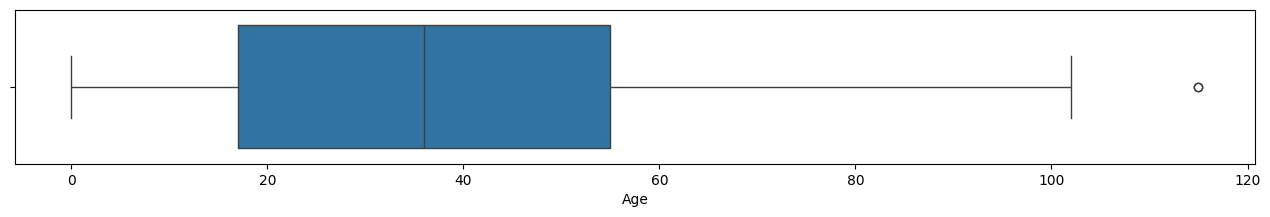

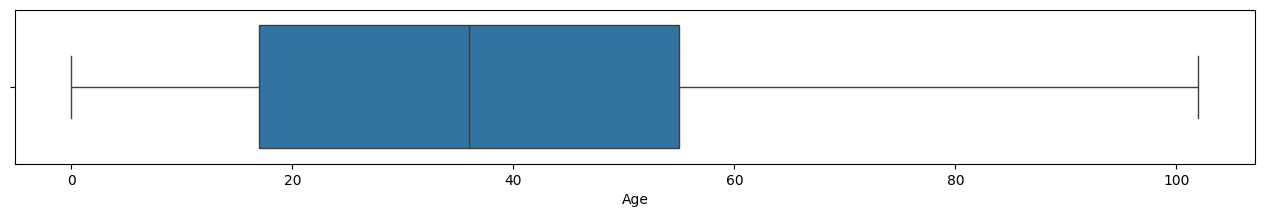

In [37]:
# 데이터 전처리
# 결측치 확인
medical.isnull().sum()        # Medical 데이터 결측치 확인
medical.isnull().any(axis=0)   # Medical 데이터 결측치 확인
medical.isnull().any(axis=1)   # Medical 데이터 결측치 확인
# 결측치 없음

# 이상치 확인 및 제거
medical.Age.unique()
medical = medical[medical.Age >= 0]   # 나이 이상치 제거
plt.figure(figsize=(16, 2))
sns.boxplot(x=medical.Age)               # 나이 이상치 시각화
# => 나이 이상치 115세 
medical = medical[medical.Age <= 110]    # 나이 이상치 제거
plt.figure(figsize=(16, 2))
sns.boxplot(x=medical.Age)               # 나이 이상치 시각화

medical = medical[medical['Gender'].isin(['F', 'M'])]        # 성별 이상치 제거
medical = medical[medical['No-show'].isin(['No', 'Yes'])]    # 내원 여부 이상치 제거



In [40]:
# 데이터 처리를 위한 WaitngDay 열 추가
medical['ScheduledDay'] = pd.to_datetime(medical['ScheduledDay']).dt.date     # 예약 날짜 형식 변환
medical['AppointmentDay'] = pd.to_datetime(medical['AppointmentDay']).dt.date # 진료 날짜 형식 변환

# WaitingDay 생성
medical['WaitingDay'] = (medical['AppointmentDay'] - medical['ScheduledDay']).apply(lambda x: x.days)  # 예약 날짜와 진료 날짜의 차이 계산
medical[['ScheduledDay', 'AppointmentDay', 'WaitingDay']]


,ScheduledDay,AppointmentDay,WaitingDay
0,2016-04-29,2016-04-29,0
1,2016-04-29,2016-04-29,0
2,2016-04-29,2016-04-29,0
3,2016-04-29,2016-04-29,0
4,2016-04-29,2016-04-29,0
...,...,...,...
65530,2016-04-20,2016-05-19,29
65531,2016-04-20,2016-05-06,16
65532,2016-04-20,2016-05-13,23
65533,2016-04-20,2016-05-20,30


In [ ]:
# 데이터 변수 간의 분석 시각화

sns.heatmap



# 방문 당일 예약한 

# 나이가 많을수록 잘 잊어서 노쇼를 자주 할 확률
# 나이가 어릴수록 책임감이 부족해 노쇼를 자주 할 확률
# sms 문자를 받지 않은 사람이 노쇼를 자주 할 것이다 => 상관관계를 확인할 것
# 예약일 ~ 진료일까지 기간이 길면 노쇼를 자주 할 것이다 => 상관관계를 확인할 것
# 지역간의 노쇼 상관관계 어떤 지역이 노쇼를 잘 당하는지

